In [1]:
import jinja2

In [2]:
template_str: str = """
Hi my name is {{name}}.
I am {{age}} old.
I Live in {{city}}.
"""

In [6]:
# Create jinja template object from a string

template = jinja2.Environment(
loader = jinja2.BaseLoader
).from_string(template_str)


<Template memory:29668d4af50>

In [9]:
# Reader  data in jinja template object

context:dict = {"name": "Ashish", "age":32,"city":"Mumbai"}

renderd_text:str = template.render(context)

print(renderd_text)


Hi my name is Ashish.
I am 32 old.
I Live in Mumbai.


-----

#### Load a template file 

In [10]:
from jinja2 import Environment
from jinja2 import FileSystemLoader

import jinja2

In [15]:
# Create jinja template object from file
# sales_report_template
template = Environment(
    loader = FileSystemLoader("./templates"),
    autoescape = jinja2.select_autoescape # enable html escaping 
).get_template("bio_template.txt")


In [17]:
context:dict = {"name": "Ashish", "age":32,"city":"Mumbai"}

renderd_text:str = template.render(context)

# write the output into a text file

with open(f'./files/bio_{context.get("name","")}.txt', mode = "w") as f:
    f.write(renderd_text)

--- 

In [18]:
template = Environment(
    loader = FileSystemLoader("./templates"),
    autoescape = jinja2.select_autoescape # enable html escaping 
).get_template("invite_template.txt")


In [19]:
#  Data for injecting into jinja2 template

template_context = {
    "recipientName": "",
    "eventDtStr": "Sunday, October 27, 2024",
    "venuStr": "Patiala",
    "senderName": "Ashish Bindra",
    "contactInfo": "9041213440",
    "time":"10: 30 A.M"
}

guests = {"Sreshti", "Akash", "Duby", "Vivek", "Vishal", "Maajid", "jitesh", "Priyanka", "Amrinder"}

In [21]:
import os

os.mkdir("files/invites")

In [1]:
int("a")

ValueError: invalid literal for int() with base 10: 'a'

In [23]:
for guest in guests:
    template_context["recipientName"] = guest
    
    # rander data in jinja template
    invite_text = template.render(template_context)
    
    # make a file
    with open(f"./files/invites/{guest}.txt", "w") as f:
        f.write(invite_text)

In [ ]:
{{senderName}}
{{contactInfo}}
{{recipientName}},
{{venuStr}}
{{eventDtStr}}
{{time}}
Sunday, October 27, 2024

---


In [123]:
from random import randint
from datetime import datetime

In [124]:
template = Environment(
    loader = FileSystemLoader("./templates"),
    autoescape = jinja2.select_autoescape # enable html escaping 
).get_template("sales_report_template.html")


In [125]:
today_date: str = datetime.now().strftime("%d-%b-%Y")
today_date

'12-Sep-2024'

In [126]:
# create data for report

today_date: str = datetime.now().strftime("%d-%b-%Y")

sales_table = []

for i,_ in enumerate(range(10),start=1):
#     print(i)
    cost_pr_unit = randint(1,15)
    num_units = randint(100,1500)

    sales_table.append({
        "sNo": i,
        "name": "Item " + str(i),
        "cPu": cost_pr_unit,
        "nUnits": num_units,
        "revenue": cost_pr_unit * num_units
    })

top_items = [x["name"] for x in sorted( sales_table, key = lambda x: x["revenue"], reverse = True)][:3] 
             

In [127]:
# Create logo image from file
import base64

with open("./files/bird-logo.avif", "rb") as f:
    logo_img = base64.b64encode(f.read()).decode()

'...'

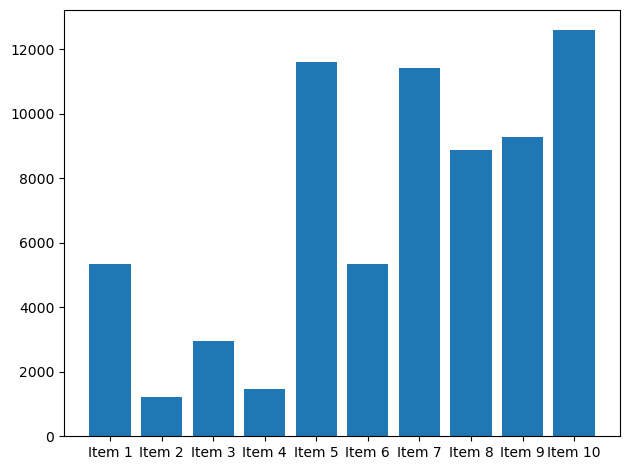

In [128]:
#  Generate sales bae chart image
from matplotlib import pyplot as plt
import io 

plot_img_bytes = io.BytesIO()

fig, ax = plt.subplots()

ax.bar([x["name"] for x in sales_table], [x["revenue"] for x in sales_table])

fig.tight_layout()
fig.savefig(plot_img_bytes, format="jpg")

plot_img_bytes.seek(0)

plot_img_str: str = base64.b64encode(plot_img_bytes.read()).decode()
plot_img_str

In [95]:
# Data for injecting into jinja2 template

context = {
    "reportDtStr": today_date,
    "salesTblRows": sales_table,
    "topItemsRows": top_items,
    "salesBarChartImg": plot_img_str,
    "logoImg": logo_img
}

In [129]:
# Data for injecting into jinja2 template

context = {
    "reportDtStr": today_date,
    "salesTblRows": sales_table,
    "topItemsRows": top_items,
#     "salesBarChartImg": plot_img_str,
    "logoImg": logo_img
}

In [130]:
# Rander the data in jinja

report_text = template.render(context)

# os.mkdir("files/reports")

with open(f"./files/reports/sales_report.html", mode="w") as f:
    f.write(report_text)

--- 

In [131]:
!pip install pytest-playwright


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyppeteer 1.0.2 requires pyee<9.0.0,>=8.1.0, but you have pyee 11.1.0 which is incompatible.



  Obtaining dependency information for pytest-playwright from https://files.pythonhosted.org/packages/01/6c/3ad6697d0da2279869cb77d5a6bbb4a9c0cec670a861bf5a9f246b39433f/pytest_playwright-0.5.2-py3-none-any.whl.metadata
  Obtaining dependency information for playwright>=1.18 from https://files.pythonhosted.org/packages/ba/27/b5f21695ee2ea32fdf826e531066e5633e1056171e217bac3daeefa46017/playwright-1.46.0-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for pytest-base-url<3.0.0,>=1.0.0 from https://files.pythonhosted.org/packages/98/1c/b00940ab9eb8ede7897443b771987f2f4a76f06be02f1b3f01eb7567e24a/pytest_base_url-2.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for python-slugify<9.0.0,>=6.0.0 from https://files.pythonhosted.org/packages/a4/62/02da182e544a51a5c3ccf4b03ab79df279f9c60c5e82d5e8bec7ca26ac11/python_slugify-8.0.4-py2.py3-none-any.whl.metadata
  Obtaining dependency information for greenlet==3.0.3 from https://files.pythonhosted.org/packages/47

In [132]:
from playwright.sync_api import sync_playwright
import pathlib
import os

# convert a relative path of a local file into absolute path
# you can skip this if you have an absolute path like "C:\\Users\\James\\reports\\sales_report.html"
filePath = os.path.abspath("reports/sales_report.html")

# derive the URL path of a local file to be opened in browser
fileUrl = pathlib.Path(filePath).as_uri()

# print the file as a pdf from chromium browser using playwright
with sync_playwright() as p:
    # create a browser instance
    browser = p.chromium.launch()

    # open a new tab in the browser
    page = browser.new_page()

    # goto the URL of the HTML page
    page.goto(fileUrl)

    # change css media type to screen
    page.emulate_media(media="screen")

    # print the html page as pdf in the browser
    page.pdf(path="reports/sales_report.pdf", format="A4",
             landscape=True, margin={"top": "2cm"})
    
    # close the browser
    browser.close()


Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

#### images were not shown on this method


In [133]:
!pip install pdfkit


  Obtaining dependency information for pdfkit from https://files.pythonhosted.org/packages/64/1b/26c080096dd93936dccfd32c682bed3d5630a84aae9d493ff68afb2ae0fb/pdfkit-1.0.0-py3-none-any.whl.metadata


In [134]:
options = {
    'page-size': 'A4',
    'margin-top': '0.75in',
    'margin-right': '0.75in',
    'margin-bottom': '0.75in',
    'margin-left': '0.75in',
}

In [137]:
import pdfkit

path_wkhtmltopdf = r'C:\Program Files\wkhtmltopdf\bin\wkhtmltopdf.exe'
config = pdfkit.configuration(wkhtmltopdf=path_wkhtmltopdf)

# Convert HTML file to PDF
pdfkit.from_file('./files/reports/sales_report.html', './files/reports/output.pdf', configuration=config)


True

In [138]:
pdfkit.from_file('./files/reports/sales_report.html', './files/reports/output1.pdf', configuration=config, options=options)


True

In [139]:
!pip install weasyprint

In [1]:
from weasyprint import HTML, CSS

css = [CSS(string='''
    @page {size: A4; margin: 1cm; }
    ''')]

HTML('./files/reports/sales_report.html').write_pdf('./files/reports/weasy_sales_report.html.pdf',
    stylesheets=css)

In [2]:
!pip install html2image


  Obtaining dependency information for html2image from https://files.pythonhosted.org/packages/ef/c5/2958b772f07a65dbfb332f8a405b523fc685c9ab088a2b389796d02ad434/html2image-2.0.5-py3-none-any.whl.metadata
  Obtaining dependency information for websocket-client==1.* from https://files.pythonhosted.org/packages/5a/84/44687a29792a70e111c5c477230a72c4b957d88d16141199bf9acb7537a3/websocket_client-1.8.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/58.8 kB ? eta -:--:--
   ---------------------------------------- 58.8/58.8 kB 1.6 MB/s eta 0:00:00
  Attempting uninstall: websocket-client
    Found existing installation: websocket-client 0.58.0
    Uninstalling websocket-client-0.58.0:
      Successfully uninstalled websocket-client-0.58.0


In [4]:
from html2image import Html2Image

hti = Html2Image()
hti.screenshot(url='./files/reports/sales_report.html', save_as='python_sales.png')


['C:\\Users\\Bindra\\Desktop\\TODO\\web development\\python_sales.png']

In [7]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import os,pathlib
filePath = os.path.abspath("./files/reports/sales_report.html")

# derive the URL path of a local file to be opened in browser
html_path = pathlib.Path(filePath).as_uri()
# Set up Chrome options for headless mode
chrome_options = Options()
chrome_options.add_argument("--headless")
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--no-sandbox")
chrome_options.add_argument("--window-size=1920x1080")  # Set window size for a large screen

# Specify path to your ChromeDriver
driver = webdriver.Chrome(options=chrome_options)

# Load your HTML file (you can also load a URL)
# html_path = "./files/reports/sales_report.html"
driver.get(html_path)

# Find the dimensions of the entire page
total_height = driver.execute_script("return document.body.scrollHeight")
driver.set_window_size(1920, total_height)  # Resize the window to the full page height

# Save the screenshot as a PNG file
driver.save_screenshot("full_page_image.png")

# Quit the browser
driver.quit()
